# Collections statistics

Descriptive statistics about the **Collections** currently loaded in the Neo4j
database by `2_00_save_collections` (run that notebook first). For each
collection we report whether it is a CellDesigner disease map collection
(`*_DM_CD`) or a BEL knowledge graph (`*_KG_BEL`), and counts of its content.

This notebook is read-only: it only queries the DB and writes summary CSVs to
`RESULTS_DIR/collections_statistics/`. It must be run **after** `2_00` (the
collections must exist) and does not depend on `2_10` (the influence graph).

In [1]:
%store -r

In [2]:
import commute_dm.utils
import credentials
import momapy_kb.lpg.backends.neo4j
import momapy_kb.lpg.session
import pandas as pd

In [3]:
backend = momapy_kb.lpg.backends.neo4j.Neo4jBackend(
    hostname=credentials.NEO4J_URI,
    username=credentials.NEO4J_USERNAME,
    password=credentials.NEO4J_PASSWORD,
    notifications_min_severity="off",
)
session = momapy_kb.lpg.session.Session(backend)

## Statistics functions

Each function runs a single Cypher query and returns a `pandas.DataFrame`. The
two collection kinds have different shapes in the DB:

- **CellDesigner collections** (`COVID_DM_CD`, `PD_DM_CD`): one
  `CellDesignerMap` per `CollectionEntry`, each `Model` linked to its elements
  by `HAS_MODEL_ELEMENT`. We count the top-level model-element labels
  (`Species`, `Reaction`, `Modulation`, `Compartment`).
- **BEL collections** (`AD_KG_BEL`, `PD_KG_BEL`, `COVID_KG_BEL`, `CBM_KG_BEL`): a single
  `BELModel` per collection, with model elements linked by `HAS_NODE` and
  thematic `Subgraph` nodes linked by `HAS_SUBGRAPH`.

In [4]:
def get_collections_overview(session):
    """One row per collection: kind (CD/BEL), number of entries (maps for CD),
    and total number of model elements / nodes."""
    query = """
        MATCH (c:Collection)-[:HAS_ENTRY]->(e:CollectionEntry)
        OPTIONAL MATCH (e)-[:HAS_OBJ]->(cd:CellDesignerMap)
        OPTIONAL MATCH (e)-[:HAS_OBJ]->(bel:BELModel)
        WITH c, e, cd, bel
        OPTIONAL MATCH (cd)-[:HAS_MODEL]->(:CellDesignerModel)-[:HAS_MODEL_ELEMENT]->(cd_el)
        OPTIONAL MATCH (bel)-[:HAS_NODE]->(bel_node) WHERE NOT bel_node:Subgraph
        RETURN
            c.name AS collection,
            CASE WHEN count(DISTINCT cd) > 0 THEN "CellDesigner" ELSE "BEL" END AS kind,
            count(DISTINCT e) AS n_entries,
            count(DISTINCT cd_el) + count(DISTINCT bel_node) AS n_elements
        ORDER BY collection
    """
    rows = session.execute_query(query)
    df = pd.DataFrame(
        [dict(row) for row in rows],
        columns=["collection_name", "language", "n_entries", "n_nodes"],
    )
    return df.sort_values("n_elements", ascending=False).reset_index(drop=True)

In [5]:
def get_cd_collections_statistics(session):
    """Per CellDesigner collection: total counts of species, reactions,
    modulations and compartments across all of its maps, plus the number of
    distinct proteins (by `hgnc.symbol` annotation)."""
    query = """
        MATCH (c:Collection)-[:HAS_ENTRY]->(:CollectionEntry)
            -[:HAS_OBJ]->(:CellDesignerMap)-[:HAS_MODEL]->(m:CellDesignerModel)
            -[:HAS_MODEL_ELEMENT]->(e)
        RETURN
            c.name AS collection,
            sum(CASE WHEN e:Species THEN 1 ELSE 0 END) AS species,
            sum(CASE WHEN e:Reaction THEN 1 ELSE 0 END) AS reactions,
            sum(CASE WHEN e:Modulation THEN 1 ELSE 0 END) AS modulations,
            sum(CASE WHEN e:Compartment THEN 1 ELSE 0 END) AS compartments
        ORDER BY collection
    """
    counts = pd.DataFrame(
        [dict(r) for r in session.execute_query(query)],
        columns=["collection", "species", "reactions", "modulations", "compartments"],
    )
    # Distinct proteins by hgnc.symbol annotation (same notion of "protein" the
    # interface analysis in 3_00 uses):
    query = """
        MATCH (c:Collection)-[:HAS_ENTRY]->(:CollectionEntry)
            -[:HAS_ELEMENT_TO_ANNOTATIONS]->(:Mapping)
            -[:HAS_ITEM]->(:Item)-[:HAS_VALUE]->(:Bag)-[:HAS_ITEM]->(a:RDFAnnotation)
        UNWIND a.resources AS resource
        WITH c.name AS collection, resource
        WHERE resource CONTAINS "hgnc.symbol"
        RETURN collection, count(DISTINCT split(resource, ":")[-1]) AS distinct_hgnc_symbols
        ORDER BY collection
    """
    symbols = pd.DataFrame(
        [dict(r) for r in session.execute_query(query)],
        columns=["collection", "distinct_hgnc_symbols"],
    )
    df = counts.merge(symbols, on="collection", how="left")
    return df.sort_values("species", ascending=False).reset_index(drop=True)

In [6]:
def get_cd_species_breakdown(session):
    """Per CellDesigner collection: number of species of each CellDesigner
    species class (Protein, Complex, SimpleMolecule, RNA, Gene, ...)."""
    query = """
        MATCH (c:Collection)-[:HAS_ENTRY]->(:CollectionEntry)
            -[:HAS_OBJ]->(:CellDesignerMap)-[:HAS_MODEL]->(:CellDesignerModel)
            -[:HAS_MODEL_ELEMENT]->(e:Species)
        WITH c.name AS collection, [l IN labels(e) WHERE NOT l IN [
            "BaseNode", "MapElement", "ModelElement", "CellDesignerModelElement", "Species"
        ]][0] AS species_class
        RETURN collection, species_class, count(*) AS n
        ORDER BY collection, n DESC
    """
    df = pd.DataFrame(
        [dict(r) for r in session.execute_query(query)],
        columns=["collection", "species_class", "n"],
    )
    pivot = (
        df.pivot(index="species_class", columns="collection", values="n")
        .fillna(0)
        .astype(int)
    )
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]
    pivot["Total"] = pivot.sum(axis=1)
    return pivot

In [7]:
def get_bel_collections_statistics(session):
    """Per BEL collection: number of model nodes, number of thematic subgraphs,
    and number of (non-structural) relationships among its nodes."""
    query = """
        MATCH (c:Collection)-[:HAS_ENTRY]->(:CollectionEntry)-[:HAS_OBJ]->(m:BELModel)
        RETURN
            c.name AS collection,
            count { (m)-[:HAS_NODE]->(n) WHERE NOT n:Subgraph } AS n_nodes,
            count { (m)-[:HAS_SUBGRAPH]->(:Subgraph) } AS n_subgraphs
        ORDER BY collection
    """
    nodes = pd.DataFrame(
        [dict(r) for r in session.execute_query(query)],
        columns=["collection", "n_nodes", "n_subgraphs"],
    )
    query = """
        MATCH (c:Collection)-[:HAS_ENTRY]->(:CollectionEntry)-[:HAS_OBJ]->(m:BELModel)
        MATCH (m)-[:HAS_NODE]->(a)-[r]->(b)<-[:HAS_NODE]-(m)
        WHERE NOT type(r) STARTS WITH "HAS_"
        RETURN c.name AS collection, count(r) AS n_relationships
        ORDER BY collection
    """
    rels = pd.DataFrame(
        [dict(r) for r in session.execute_query(query)],
        columns=["collection", "n_relationships"],
    )
    df = nodes.merge(rels, on="collection", how="left")
    return df.sort_values("n_nodes", ascending=False).reset_index(drop=True)

In [8]:
def get_bel_node_breakdown(session):
    """Per BEL collection: number of nodes of each BEL element class."""
    query = """
        MATCH (c:Collection)-[:HAS_ENTRY]->(:CollectionEntry)-[:HAS_OBJ]->(m:BELModel)
            -[:HAS_NODE]->(n)
        WHERE NOT n:Subgraph
        WITH c.name AS collection, [l IN labels(n) WHERE NOT l IN [
            "BELModelElement", "BioConcept", "GeneticFlow"
        ]][0] AS node_class
        RETURN collection, node_class, count(*) AS n
        ORDER BY collection, n DESC
    """
    df = pd.DataFrame(
        [dict(r) for r in session.execute_query(query)],
        columns=["collection", "node_class", "n"],
    )
    pivot = (
        df.pivot(index="node_class", columns="collection", values="n")
        .fillna(0)
        .astype(int)
    )
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]
    pivot["Total"] = pivot.sum(axis=1)
    return pivot

In [9]:
def get_bel_relationship_breakdown(session):
    """Per BEL collection: number of (non-structural) relationships of each BEL
    relation type among its nodes. BEL relations fall into causal
    (INCREASES/DECREASES/..., REGULATES, CAUSES_NO_CHANGE), correlative
    (ASSOCIATION, POSITIVE/NEGATIVE_CORRELATION), hierarchical (IS_A),
    equivalence (ORTHOLOGOUS, EQUIVALENT_TO) and transformation (TRANSLATED_TO)
    families. Only the causal family is carried into the influence graph by
    `ig.make_ig_in_db`."""
    query = """
        MATCH (c:Collection)-[:HAS_ENTRY]->(:CollectionEntry)-[:HAS_OBJ]->(m:BELModel)
        MATCH (m)-[:HAS_NODE]->(a)-[r]->(b)<-[:HAS_NODE]-(m)
        WHERE NOT type(r) STARTS WITH "HAS_"
        RETURN c.name AS collection, type(r) AS relation_type, count(r) AS n
        ORDER BY collection, n DESC
    """
    df = pd.DataFrame(
        [dict(r) for r in session.execute_query(query)],
        columns=["collection", "relation_type", "n"],
    )
    pivot = (
        df.pivot(index="relation_type", columns="collection", values="n")
        .fillna(0)
        .astype(int)
    )
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]
    pivot["Total"] = pivot.sum(axis=1)
    return pivot

In [10]:
def get_bel_endpoint_type_pair_breakdown(session):
    """Per BEL collection: number of (non-structural) relationships for each
    *unordered* pair of endpoint node classes (e.g. Protein - Protein,
    BiologicalProcess - Protein). Endpoint classes are the same primary BEL
    labels used in `get_bel_node_breakdown`; the pair is order-independent, so
    a Protein->BiologicalProcess and a BiologicalProcess->Protein edge are
    counted together."""
    query = """
        MATCH (c:Collection)-[:HAS_ENTRY]->(:CollectionEntry)-[:HAS_OBJ]->(m:BELModel)
        MATCH (m)-[:HAS_NODE]->(a)-[r]->(b)<-[:HAS_NODE]-(m)
        WHERE NOT type(r) STARTS WITH "HAS_"
        WITH c.name AS collection,
            [l IN labels(a) WHERE NOT l IN ["BELModelElement", "BioConcept", "GeneticFlow", "Subgraph"]][0] AS source_class,
            [l IN labels(b) WHERE NOT l IN ["BELModelElement", "BioConcept", "GeneticFlow", "Subgraph"]][0] AS target_class
        WITH collection, apoc.coll.sort([source_class, target_class]) AS pair
        RETURN collection, pair[0] + " - " + pair[1] AS type_pair, count(*) AS n
        ORDER BY collection, n DESC
    """
    df = pd.DataFrame(
        [dict(r) for r in session.execute_query(query)],
        columns=["collection", "type_pair", "n"],
    )
    pivot = (
        df.pivot(index="type_pair", columns="collection", values="n")
        .fillna(0)
        .astype(int)
    )
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]
    pivot["Total"] = pivot.sum(axis=1)
    return pivot

In [11]:
# Relationship types by which a BEL node is a *structural constituent* of a
# container: a complex/composite/list subunit, a reactant/product/argument of a
# process, or a qualified base form (variant / modification / location /
# fragment). A counted node that is only such a constituent -- i.e. carries no
# causal relationship of its own -- is scaffolding rather than an actor, so it is
# dropped from the projection below.
CONTAINMENT_REL_TYPES = [
    # aggregation (whole <-> part)
    "HAS__PROTEIN",
    "HAS__ABUNDANCE",
    "HAS__COMPLEX",
    "HAS__GENE",
    "HAS__RNA",
    "HAS__MICRO_RNA",
    "HAS_MEMBER",
    "HAS_COMPONENT",
    # qualified form (base -> specific variant / modified / located / fragmented form)
    "HAS__VARIANT",
    "HAS_VARIANT_PROTEIN",
    "HAS_VARIANT_GENE",
    "HAS_MODIFIED_PROTEIN",
    "HAS_MODIFIED_GENE",
    "HAS_FRAGMENTED_PROTEIN",
    "HAS_LOCATED_PROTEIN",
    "HAS_LOCATED_RNA",
    "HAS_LOCATED_ABUNDANCE",
]


def get_bel_projection(session):
    """Build the **projected BEL graph** shared by the degree and endpoint-group
    analyses, returned as two DataFrames ``(nodes_df, edges_df)``.

    The projection is defined once here so every downstream statistic uses the
    exact same node set and edges:

    - **Nodes** -- the *counted* BEL nodes, in two groups: **abundance/activity**
      (`Protein`, `Complex`, `Abundance`, `Gene`, `Rna`, `MicroRna`, `Composite`,
      `Variant`, `Activity`) and **biologicalprocess/pathology** (`BioConcept`)
      -- **minus structural-constituent nodes**: a node that is only a `HAS_*`
      part / qualified form of a container (see `CONTAINMENT_REL_TYPES`) *and*
      has no causal relationship of its own is dropped, because in BEL its causal
      wiring lives on the container, not on the part. Top-level entities with no
      causal edge (e.g. complexes declared but never used causally) are **kept**
      -- they are genuine entities that simply have degree 0.
    - **Edges** -- the induced non-structural relationships (`type` not starting
      with `HAS_`) whose *both* endpoints are counted nodes. Structural-only
      nodes have no such edge by construction, so every edge endpoint survives in
      ``nodes_df``.

    ``nodes_df`` columns: ``collection``, ``element_id``, ``bel``, ``node_group``,
    ``node_class``. ``edges_df`` columns: ``collection``, ``source_id``,
    ``target_id``, ``relation_type``."""
    node_query = """
        MATCH (c:Collection)-[:HAS_ENTRY]->(:CollectionEntry)-[:HAS_OBJ]->(:BELModel)
            -[:HAS_NODE]->(n)
        WITH c, n,
            CASE
                WHEN n:BioConcept THEN "biologicalprocess/pathology"
                WHEN n:Protein OR n:Complex OR n:Abundance OR n:Gene OR n:Rna
                    OR n:MicroRna OR n:Composite OR n:Variant OR n:Activity
                    THEN "abundance/activity"
                ELSE null
            END AS node_group
        WHERE node_group IS NOT NULL
            AND NOT (
                EXISTS { ()-[hc]->(n) WHERE type(hc) IN $containment_types }
                AND NOT EXISTS { (n)-[cc]-() WHERE NOT type(cc) STARTS WITH "HAS_" }
            )
        RETURN
            c.name AS collection,
            elementId(n) AS element_id,
            n.bel AS bel,
            node_group,
            [l IN labels(n) WHERE NOT l IN [
                "BELModelElement", "BioConcept", "GeneticFlow"
            ]][0] AS node_class
    """
    nodes_df = pd.DataFrame(
        [
            dict(r)
            for r in session.execute_query(
                node_query, params={"containment_types": CONTAINMENT_REL_TYPES}
            )
        ],
        columns=["collection", "element_id", "bel", "node_group", "node_class"],
    )
    edge_query = """
        MATCH (c:Collection)-[:HAS_ENTRY]->(:CollectionEntry)-[:HAS_OBJ]->(m:BELModel)
        MATCH (m)-[:HAS_NODE]->(a)-[r]->(b)<-[:HAS_NODE]-(m)
        WHERE NOT type(r) STARTS WITH "HAS_"
            AND (a:BioConcept OR a:Protein OR a:Complex OR a:Abundance OR a:Gene
                OR a:Rna OR a:MicroRna OR a:Composite OR a:Variant OR a:Activity)
            AND (b:BioConcept OR b:Protein OR b:Complex OR b:Abundance OR b:Gene
                OR b:Rna OR b:MicroRna OR b:Composite OR b:Variant OR b:Activity)
        RETURN
            c.name AS collection,
            elementId(a) AS source_id,
            elementId(b) AS target_id,
            type(r) AS relation_type
    """
    edges_df = pd.DataFrame(
        [dict(r) for r in session.execute_query(edge_query)],
        columns=["collection", "source_id", "target_id", "relation_type"],
    )
    return nodes_df, edges_df

In [12]:
def get_bel_grouped_endpoint_pair_breakdown(nodes_df, edges_df):
    """Per BEL collection: number of projected relationships for each *unordered*
    pair of coarse endpoint groups -- **abundance/activity** and
    **biologicalprocess/pathology**.

    Computed from the shared projection (`get_bel_projection`): endpoint groups
    come from ``nodes_df`` and edges from ``edges_df``, so the same node set and
    edges back this table and the degree analysis. The three rows do **not** sum
    to the collection's total relationship count, because relationships touching
    non-counted node types are not in the projection. (Dropping
    structural-constituent nodes does not change these counts: such nodes carry
    no relationship, so they contribute no edge.)"""
    group = nodes_df[["collection", "element_id", "node_group"]]
    edges = edges_df.merge(
        group.rename(columns={"element_id": "source_id", "node_group": "source_group"}),
        on=["collection", "source_id"],
    ).merge(
        group.rename(columns={"element_id": "target_id", "node_group": "target_group"}),
        on=["collection", "target_id"],
    )
    # Order-independent pair: put the two group names in a canonical order.
    swap = edges["source_group"] > edges["target_group"]
    low = edges["source_group"].where(~swap, edges["target_group"])
    high = edges["target_group"].where(~swap, edges["source_group"])
    edges = edges.assign(group_pair=low + " - " + high)
    counts = edges.groupby(["collection", "group_pair"]).size().reset_index(name="n")
    pivot = (
        counts.pivot(index="group_pair", columns="collection", values="n")
        .fillna(0)
        .astype(int)
    )
    # Fixed row order: same-group abundance, mixed, same-group bioconcept.
    row_order = [
        "abundance/activity - abundance/activity",
        "abundance/activity - biologicalprocess/pathology",
        "biologicalprocess/pathology - biologicalprocess/pathology",
    ]
    pivot = pivot.reindex(row_order).fillna(0).astype(int)
    pivot["Total"] = pivot.sum(axis=1)
    return pivot

In [13]:
def get_bel_degree_data(nodes_df, edges_df):
    """Per projected BEL node, its in- and out-degree over the projection
    (`get_bel_projection`).

    Degrees count the projected relationships (`edges_df`) incident to the node;
    a projected node with no incident edge keeps degree 0 (these are the genuine
    top-level entities with no causal statement -- structural-constituent nodes
    were already removed when the projection was built). Returns one row per
    node: `collection`, `bel`, `node_group`, `indegree`, `outdegree`."""
    indegree = (
        edges_df.groupby(["collection", "target_id"])
        .size()
        .rename_axis(["collection", "element_id"])
        .rename("indegree")
    )
    outdegree = (
        edges_df.groupby(["collection", "source_id"])
        .size()
        .rename_axis(["collection", "element_id"])
        .rename("outdegree")
    )
    df = (
        nodes_df.set_index(["collection", "element_id"])
        .join(indegree)
        .join(outdegree)
        .fillna({"indegree": 0, "outdegree": 0})
    )
    df["indegree"] = df["indegree"].astype(int)
    df["outdegree"] = df["outdegree"].astype(int)
    return df.reset_index()[
        ["collection", "bel", "node_group", "indegree", "outdegree"]
    ]

In [14]:
def fit_degree_power_law(degrees):
    """Fit a discrete power law to a 1-D array of node degrees using the
    `powerlaw` package (the Clauset-Shalizi-Newman method): MLE-estimate the
    exponent `alpha` and lower cutoff `x_min`, then compare the power law
    against a lognormal and against an exponential via normalised
    log-likelihood ratios.

    Returns a dict with `alpha`, `x_min`, the tail size `n_tail`, and for each
    alternative a ratio `R` (>0 favours the power law, <0 favours the
    alternative) with its significance `p`. The fitted `powerlaw.Fit` object is
    returned under `_fit` for plotting. Degrees of 0 are dropped (a power law
    lives on k >= x_min >= 1)."""
    import numpy as np
    import powerlaw

    degrees = np.asarray(degrees)
    degrees = degrees[degrees > 0]
    fit = powerlaw.Fit(degrees, discrete=True, verbose=False)
    r_lognormal, p_lognormal = fit.distribution_compare(
        "power_law", "lognormal", normalized_ratio=True
    )
    r_exponential, p_exponential = fit.distribution_compare(
        "power_law", "exponential", normalized_ratio=True
    )
    return {
        "n_nodes_k>0": int(degrees.size),
        "alpha": fit.alpha,
        "x_min": fit.xmin,
        "n_tail": int(fit.n_tail),
        "R_vs_lognormal": r_lognormal,
        "p_vs_lognormal": p_lognormal,
        "R_vs_exponential": r_exponential,
        "p_vs_exponential": p_exponential,
        "_fit": fit,
    }

## Overview of all collections

In [15]:
overview_df = get_collections_overview(session)
overview_df

,collection,kind,n_entries,n_elements
0,PD_DM_CD,CellDesigner,40,15594
1,COVID_DM_CD,CellDesigner,22,8831
2,AD_KG_BEL,BEL,1,5024
3,COVID_KG_BEL,BEL,1,2796
4,CBM_KG_BEL,BEL,1,2425
5,PD_KG_BEL,BEL,1,2313


## CellDesigner disease-map collections

### Element counts

In [16]:
cd_stats_df = get_cd_collections_statistics(session)
cd_stats_df

,collection,species,reactions,modulations,compartments,distinct_hgnc_symbols
0,PD_DM_CD,6996,1561,2338,534,1385
1,COVID_DM_CD,3864,1221,174,136,802


### Species breakdown by class

In [17]:
cd_species_df = get_cd_species_breakdown(session)
cd_species_df

collection,COVID_DM_CD,PD_DM_CD,Total
species_class,,,
Protein,2449,3782,6231
Complex,573,1129,1702
SimpleMolecule,366,832,1198
Phenotype,110,610,720
RNA,160,374,534
Ion,62,198,260
Drug,80,46,126
Gene,64,25,89


## BEL knowledge-graph collections

### Node, subgraph and relationship counts

In [18]:
bel_stats_df = get_bel_collections_statistics(session)
bel_stats_df

,collection,n_nodes,n_subgraphs,n_relationships
0,AD_KG_BEL,5024,124,8896
1,COVID_KG_BEL,2796,1,2944
2,CBM_KG_BEL,2425,1,4277
3,PD_KG_BEL,2313,66,3406


### Node breakdown by class

In [19]:
bel_nodes_df = get_bel_node_breakdown(session)
bel_nodes_df.head(20)  # full table written to CSV below

collection,AD_KG_BEL,CBM_KG_BEL,COVID_KG_BEL,PD_KG_BEL,Total
node_class,,,,,
Protein,1711,476,683,862,3732
Complex,798,60,799,146,1803
Abundance,476,378,549,220,1623
BiologicalProcess,446,339,171,299,1255
Activity,549,61,87,137,834
Pathology,127,394,171,93,785
Gene,219,35,103,242,599
Rna,115,394,25,39,573
Variant,125,56,7,145,333


### Relationship breakdown by type

The BEL relation types grouped by family: **causal** (`INCREASES`, `DECREASES`,
their `DIRECTLY_*` variants, `REGULATES`, `CAUSES_NO_CHANGE`), **correlative**
(`ASSOCIATION`, `POSITIVE_CORRELATION`, `NEGATIVE_CORRELATION`), **hierarchical**
(`IS_A`), **equivalence** (`ORTHOLOGOUS`, `EQUIVALENT_TO`) and **transformation**
(`TRANSLATED_TO`). Only the causal family is carried into the influence graph by
`ig.make_ig_in_db`.

In [20]:
bel_relationships_df = get_bel_relationship_breakdown(session)
bel_relationships_df

collection,AD_KG_BEL,CBM_KG_BEL,COVID_KG_BEL,PD_KG_BEL,Total
relation_type,,,,,
INCREASES,4056,2244,765,1476,8541
DECREASES,1598,613,868,594,3673
ASSOCIATION,1877,182,456,727,3242
POSITIVE_CORRELATION,528,847,183,307,1865
NEGATIVE_CORRELATION,335,247,141,182,905
REGULATES,155,105,251,9,520
IS_A,67,7,243,33,350
CAUSES_NO_CHANGE,58,32,9,60,159
DIRECTLY_INCREASES,114,0,6,6,126


### Relationship breakdown by endpoint type pair

Number of relationships for each *unordered* pair of endpoint node classes
(e.g. `Protein - Protein`, `BiologicalProcess - Protein`). The pair is
order-independent: an edge from a Protein to a BiologicalProcess and one in the
opposite direction are counted under the same `BiologicalProcess - Protein`
pair.

In [21]:
bel_type_pairs_df = get_bel_endpoint_type_pair_breakdown(session)
bel_type_pairs_df.head(20)  # full table written to CSV below

collection,AD_KG_BEL,CBM_KG_BEL,COVID_KG_BEL,PD_KG_BEL,Total
type_pair,,,,,
BiologicalProcess - Protein,1020,267,322,581,2190
Protein - Protein,996,118,198,549,1861
Pathology - Protein,779,461,154,364,1758
Abundance - Protein,922,189,342,195,1648
Abundance - Pathology,289,463,614,75,1441
Activity - Protein,879,20,41,190,1130
Abundance - BiologicalProcess,376,304,228,119,1027
Pathology - Pathology,73,588,112,43,816
Abundance - Abundance,243,89,303,59,694


### The projected BEL graph

The remaining BEL analyses (the coarse endpoint-group pairs below, and the
degree / scale-free analyses further down) all operate on a single **projected
graph**, built once by `get_bel_projection` so they share exactly the same node
set and edges:

- **Nodes**: the counted BEL entities (the *abundance/activity* group and the
  *biologicalprocess/pathology* group), **minus structural-constituent nodes** —
  a node that is only a `HAS_*` part or qualified form of a container (a complex
  subunit, a process reactant, a variant/modified/located base form) and carries
  no causal relationship of its own. In BEL such a node's causal wiring lives on
  its container, so counting it as a separate node would just inflate the
  degree-0 mass. Top-level entities that happen to have no causal statement
  (e.g. complexes declared but never used causally) are **kept** — they are
  genuine entities with degree 0.
- **Edges**: the induced non-structural (non-`HAS_`) relationships whose both
  endpoints are counted nodes.

In [22]:
bel_projection_nodes, bel_projection_edges = get_bel_projection(session)
print(
    "projected nodes per KG:",
    bel_projection_nodes.groupby("collection").size().to_dict(),
)
print(
    "projected edges per KG:",
    bel_projection_edges.groupby("collection").size().to_dict(),
)

projected nodes per KG: {'AD_KG_BEL': 4099, 'CBM_KG_BEL': 2084, 'COVID_KG_BEL': 2278, 'PD_KG_BEL': 1930}
projected edges per KG: {'AD_KG_BEL': 8417, 'CBM_KG_BEL': 3905, 'COVID_KG_BEL': 2879, 'PD_KG_BEL': 3304}


### Relationship breakdown by coarse endpoint group pair

The projected relationships (from `get_bel_projection` above) collapsed onto two
coarse endpoint groups: **abundance/activity** (abundance-type entities and
their activities: `Protein`, `Complex`, `Abundance`, `Gene`, `Rna`, `MicroRna`,
`Composite`, `Variant`, `Activity`) and **biologicalprocess/pathology** (the
`BioConcept` nodes, BiologicalProcess and Pathology). Only relationships whose
*both* endpoints are counted nodes are tallied, so -- unlike the whole-graph
tables above -- these three rows do **not** sum to the collection's total
relationship count.

In [23]:
bel_group_pairs_df = get_bel_grouped_endpoint_pair_breakdown(
    bel_projection_nodes, bel_projection_edges
)
bel_group_pairs_df

collection,AD_KG_BEL,CBM_KG_BEL,COVID_KG_BEL,PD_KG_BEL,Total
group_pair,,,,,
abundance/activity - abundance/activity,4635,722,1216,1509,8082
abundance/activity - biologicalprocess/pathology,3400,2128,1481,1574,8583
biologicalprocess/pathology - biologicalprocess/pathology,382,1055,182,221,1840


## Writing the statistics to disk

We write each table as a CSV under `RESULTS_DIR/collections_statistics/`.

In [24]:
COLLECTIONS_STATISTICS_DIR = RESULTS_DIR / "collections_statistics/"
commute_dm.utils.remake_dir(COLLECTIONS_STATISTICS_DIR)

overview_df.to_csv(COLLECTIONS_STATISTICS_DIR / "overview.csv", index=False)
cd_stats_df.to_csv(COLLECTIONS_STATISTICS_DIR / "cd_element_counts.csv", index=False)
cd_species_df.to_csv(COLLECTIONS_STATISTICS_DIR / "cd_species_breakdown.csv")
bel_stats_df.to_csv(COLLECTIONS_STATISTICS_DIR / "bel_node_counts.csv", index=False)
bel_nodes_df.to_csv(COLLECTIONS_STATISTICS_DIR / "bel_node_breakdown.csv")
bel_relationships_df.to_csv(
    COLLECTIONS_STATISTICS_DIR / "bel_relationship_breakdown.csv"
)
bel_type_pairs_df.to_csv(
    COLLECTIONS_STATISTICS_DIR / "bel_endpoint_type_pair_breakdown.csv"
)
bel_group_pairs_df.to_csv(
    COLLECTIONS_STATISTICS_DIR / "bel_grouped_endpoint_pair_breakdown.csv"
)

## Are the BEL KGs scale-free? Degree distributions and power-law fits

For each of the four BEL KGs we test whether its degree distribution is
**scale-free** (i.e. follows a power law `P(k) ~ k^-alpha`). We use the shared
projected graph built above by `get_bel_projection` (the **abundance/activity**
and **biologicalprocess/pathology** node groups, with structural-constituent
nodes removed, and only relationships whose both endpoints are counted nodes)
and look at in-degree, out-degree and total degree separately.

Two ingredients, following Clauset, Shalizi & Newman (2009):

1. **Log-log CCDF** — the complementary cumulative distribution `P(K >= k)`,
   plotted on log-log axes (no binning artifacts). A straight line is the
   visual signature of a power law.
2. **A `powerlaw` fit** — MLE estimate of the exponent `alpha` and the lower
   cutoff `x_min`, plus normalised likelihood-ratio tests of the power law
   against a **lognormal** and an **exponential** alternative. `R > 0` favours
   the power law; `p` is the significance. A distribution is convincingly
   scale-free only if the power law is not rejected *and* is favoured over these
   alternatives (in practice a heavy tail is often statistically
   indistinguishable from a lognormal).

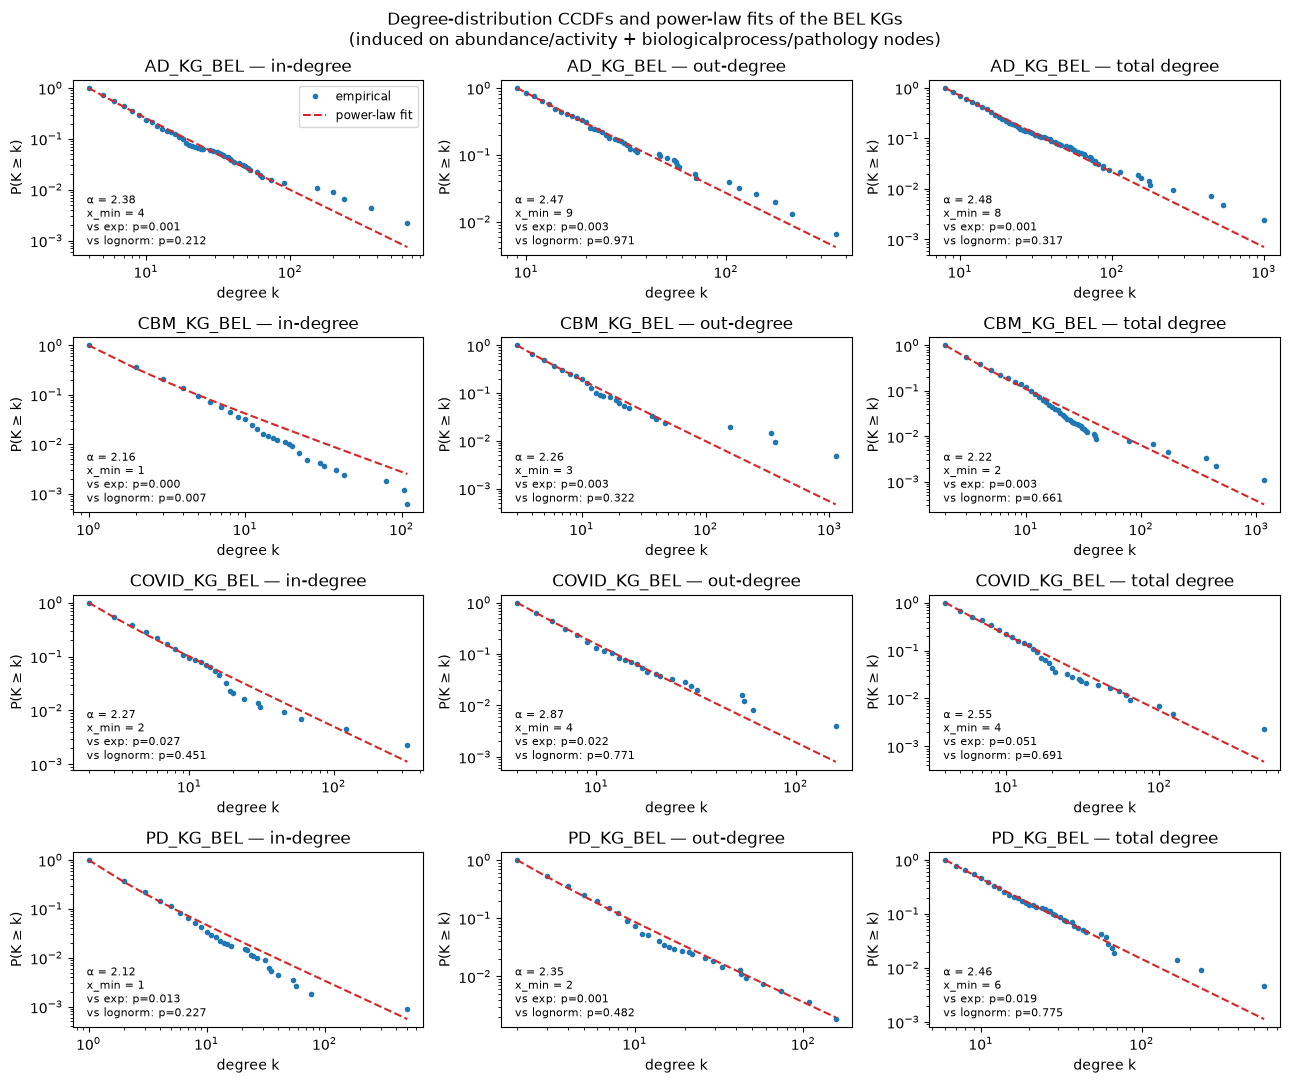

,collection,degree,n_nodes_k>0,alpha,x_min,n_tail,R_vs_lognormal,p_vs_lognormal,R_vs_exponential,p_vs_exponential
0,AD_KG_BEL,in-degree,2373,2.380349,4.0,452,1.247194,0.212326,3.288955,0.001006
1,AD_KG_BEL,out-degree,2353,2.469822,9.0,154,-0.036597,0.970806,3.016805,0.002555
2,AD_KG_BEL,total degree,3581,2.482248,8.0,419,-1.001147,0.316756,3.390588,0.000697
3,CBM_KG_BEL,in-degree,1639,2.157056,1.0,1639,-2.674003,0.007495,4.498241,0.000007
4,CBM_KG_BEL,out-degree,677,2.258999,3.0,208,-0.990526,0.321917,2.987359,0.002814
5,CBM_KG_BEL,total degree,2025,2.217575,2.0,903,-0.438626,0.660933,2.947344,0.003205
6,COVID_KG_BEL,in-degree,895,2.272604,2.0,433,-0.754234,0.450708,2.215536,0.026723
7,COVID_KG_BEL,out-degree,849,2.874023,4.0,246,0.291002,0.771050,2.298864,0.021513
8,COVID_KG_BEL,total degree,1504,2.554900,4.0,426,-0.397679,0.690867,1.947730,0.051447
9,PD_KG_BEL,in-degree,1115,2.116113,1.0,1115,-1.208670,0.226790,2.491660,0.012715


In [25]:
import warnings

import matplotlib.pyplot as plt
import powerlaw

BEL_COLLECTIONS = ["AD_KG_BEL", "CBM_KG_BEL", "COVID_KG_BEL", "PD_KG_BEL"]
DEGREE_TYPES = [
    ("indegree", "in-degree"),
    ("outdegree", "out-degree"),
    ("total", "total degree"),
]

degree_df = get_bel_degree_data(bel_projection_nodes, bel_projection_edges)
degree_df = degree_df.assign(total=degree_df["indegree"] + degree_df["outdegree"])

# Fit a power law to each (collection, degree-type) and collect the verdicts.
records = []
fits = {}
with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # powerlaw is chatty about xmin / divide-by-zero
    for collection in BEL_COLLECTIONS:
        sub = degree_df[degree_df["collection"] == collection]
        for degree_col, label in DEGREE_TYPES:
            result = fit_degree_power_law(sub[degree_col].to_numpy())
            fits[(collection, degree_col)] = result.pop("_fit")
            records.append({"collection": collection, "degree": label, **result})

scale_free_df = pd.DataFrame(records)

# Log-log CCDFs with the fitted power-law tail overlaid (rows = KG, cols = degree type).
fig, axes = plt.subplots(
    len(BEL_COLLECTIONS), len(DEGREE_TYPES), figsize=(13, 11), squeeze=False
)
for i, collection in enumerate(BEL_COLLECTIONS):
    for j, (degree_col, label) in enumerate(DEGREE_TYPES):
        ax = axes[i][j]
        fit = fits[(collection, degree_col)]
        fit.plot_ccdf(
            ax=ax, color="tab:blue", marker=".", linestyle="none", label="empirical"
        )
        fit.power_law.plot_ccdf(
            ax=ax, color="tab:red", linestyle="--", label="power-law fit"
        )
        row = scale_free_df[
            (scale_free_df["collection"] == collection)
            & (scale_free_df["degree"] == label)
        ].iloc[0]
        ax.set_title(f"{collection} — {label}")
        ax.set_xlabel("degree k")
        ax.set_ylabel("P(K ≥ k)")
        ax.text(
            0.04,
            0.04,
            f"α = {row['alpha']:.2f}\nx_min = {row['x_min']:.0f}\n"
            f"vs exp: p={row['p_vs_exponential']:.3f}\n"
            f"vs lognorm: p={row['p_vs_lognormal']:.3f}",
            transform=ax.transAxes,
            va="bottom",
            ha="left",
            fontsize=8,
        )
        if i == 0 and j == 0:
            ax.legend(fontsize="small", loc="upper right")

fig.suptitle(
    "Degree-distribution CCDFs and power-law fits of the BEL KGs\n"
    "(induced on abundance/activity + biologicalprocess/pathology nodes)"
)
fig.tight_layout()
fig.savefig(
    COLLECTIONS_STATISTICS_DIR / "bel_degree_scalefree.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

scale_free_df.to_csv(
    COLLECTIONS_STATISTICS_DIR / "bel_scale_free_fits.csv", index=False
)
scale_free_df

### Comparing the degree distributions across the four KGs

We put the four KGs side by side, for in-, out- and total degree:

- **Overlaid CCDFs** on shared log-log axes (one panel per degree type). Each
  CCDF is computed over *all* projected nodes, so the height at `k = 1` is the
  fraction of non-isolated nodes -- a lower starting point means a sparser
  graph. Since structural-constituent nodes were already removed, the remaining
  degree-0 nodes are genuine entities with no causal statement (for COVID, the
  many complexes declared but never used causally).
- A **shape/summary table** (number of nodes, % isolated, mean / median / p90 /
  max degree).
- **Pairwise two-sample Kolmogorov–Smirnov tests** between KGs, reported as the
  effect size `KS_D` only (the p-value is deliberately omitted — see next).

#### Reading the KS test: use `KS_D`, and why the p-value is omitted

The two-sample Kolmogorov–Smirnov statistic **`KS_D`** is the largest vertical
gap between the two KGs' empirical cumulative degree distributions,
`KS_D = max_k |F_1(k) − F_2(k)|`. It runs from **0** (the two degree
distributions are identical) to **1** (they never overlap), and it is a pure
*shape* comparison that does **not** depend on how many nodes each KG has. This
is the number to read: `KS_D ≈ 0.19–0.30` (any pair involving COVID) is a real,
substantial difference in shape, whereas `KS_D ≈ 0.03–0.09` (AD vs PD) means the
two distributions are nearly interchangeable.

We **do not tabulate the p-value**, because here it answers a different question
— *"if both KGs were random samples drawn from one single underlying
distribution, how surprising would a gap this large be?"* — that is not
informative for us, for two reasons:

1. **We are not sampling.** Each KG is essentially the *whole* graph, not a draw
   from some larger population, so the null hypothesis the p-value tests ("both
   come from the same population") is not a question we are actually asking. The
   KGs are simply different curated resources; that they differ is a given, not
   a hypothesis to test.
2. **At this n the p-value just reports sample size, not effect size.** The
   p-value is driven by `KS_D` *and* by n (~1900–4100 nodes here). With samples
   this large the test has enormous power, so *any* non-zero difference — even a
   biologically trivial one — comes out "highly significant." AD vs PD is the
   giveaway: a tiny `KS_D ≈ 0.086` still gives `p ≈ 7e-9`. And because the size
   of p tracks n far more than it tracks the difference, p-values **cannot** be
   used to rank pairs (a smaller p does not mean "more different") — only `KS_D`
   supports that comparison.

So the table reports `KS_D` alone, as the effect size that actually measures
*how much* two degree distributions differ.

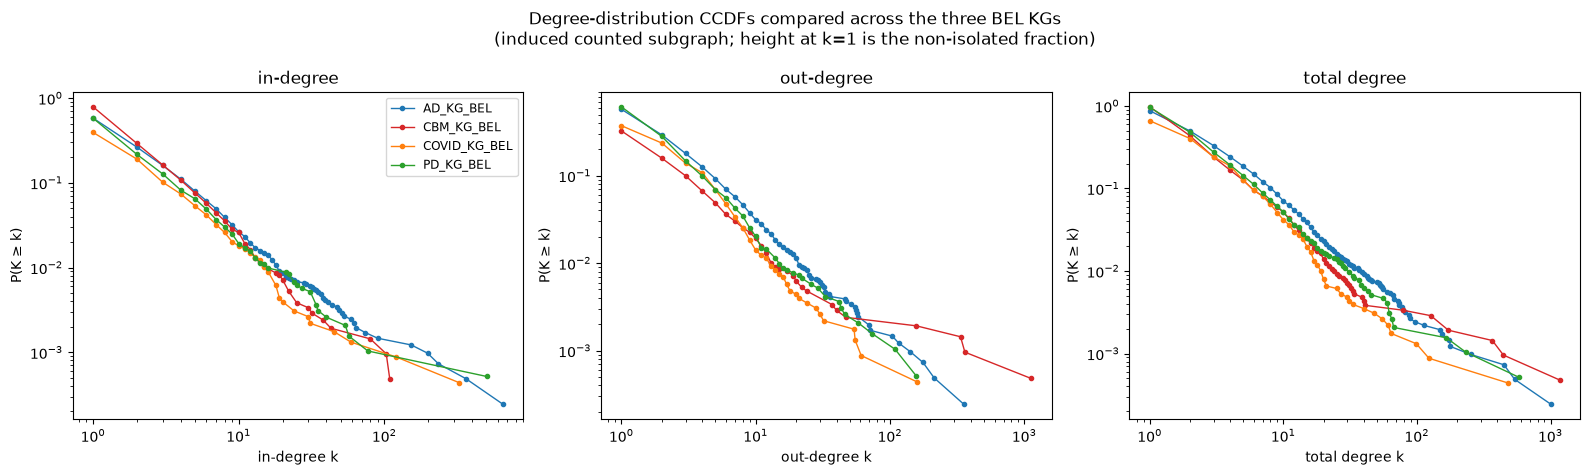

,collection,degree,n_nodes,pct_isolated,mean,median,p90,max
0,AD_KG_BEL,in-degree,4099,42.107831,2.053428,1.0,4.0,651
1,AD_KG_BEL,out-degree,4099,42.595755,2.053428,1.0,4.0,354
2,AD_KG_BEL,total degree,4099,12.637229,4.106855,1.0,8.0,1005
3,CBM_KG_BEL,in-degree,2084,21.353167,1.873800,1.0,4.0,109
4,CBM_KG_BEL,out-degree,2084,67.514395,1.873800,0.0,2.0,1125
5,CBM_KG_BEL,total degree,2084,2.831094,3.747601,1.0,5.0,1168
6,COVID_KG_BEL,in-degree,2278,60.711150,1.263828,0.0,3.0,325
7,COVID_KG_BEL,out-degree,2278,62.730465,1.263828,0.0,4.0,159
8,COVID_KG_BEL,total degree,2278,33.977173,2.527656,1.0,5.0,484
9,PD_KG_BEL,in-degree,1930,42.227979,1.711917,1.0,3.0,504


,degree,pair,KS_D
0,in-degree,AD_KG_BEL vs CBM_KG_BEL,0.207547
1,in-degree,AD_KG_BEL vs COVID_KG_BEL,0.186033
2,in-degree,AD_KG_BEL vs PD_KG_BEL,0.047173
3,in-degree,CBM_KG_BEL vs COVID_KG_BEL,0.393580
4,in-degree,CBM_KG_BEL vs PD_KG_BEL,0.208748
5,in-degree,COVID_KG_BEL vs PD_KG_BEL,0.184832
6,out-degree,AD_KG_BEL vs CBM_KG_BEL,0.249186
7,out-degree,AD_KG_BEL vs COVID_KG_BEL,0.201347
8,out-degree,AD_KG_BEL vs PD_KG_BEL,0.037357
9,out-degree,CBM_KG_BEL vs COVID_KG_BEL,0.077384


In [26]:
import itertools

import numpy as np
from IPython.display import display
from scipy import stats

CROSS_KG_COLORS = {
    "AD_KG_BEL": "tab:blue",
    "CBM_KG_BEL": "tab:red",
    "COVID_KG_BEL": "tab:orange",
    "PD_KG_BEL": "tab:green",
}


def _degree_array(collection, degree_col):
    return degree_df.loc[degree_df["collection"] == collection, degree_col].to_numpy()


# Shape/summary descriptors per (collection, degree type).
summary_records = []
for collection in BEL_COLLECTIONS:
    for degree_col, label in DEGREE_TYPES:
        values = _degree_array(collection, degree_col)
        summary_records.append(
            {
                "collection": collection,
                "degree": label,
                "n_nodes": int(values.size),
                "pct_isolated": 100 * (values == 0).mean(),
                "mean": values.mean(),
                "median": float(np.median(values)),
                "p90": float(np.percentile(values, 90)),
                "max": int(values.max()),
            }
        )
cross_kg_summary_df = pd.DataFrame(summary_records)

# Pairwise two-sample KS tests between KGs (full per-node degree vectors). We keep
# only KS_D: at this sample size the p-value is a foregone "significant" and is
# not a meaningful effect measure (see the markdown above), so we omit it.
ks_records = []
for degree_col, label in DEGREE_TYPES:
    for c1, c2 in itertools.combinations(BEL_COLLECTIONS, 2):
        ks_d, _p_value = stats.ks_2samp(
            _degree_array(c1, degree_col), _degree_array(c2, degree_col)
        )
        ks_records.append({"degree": label, "pair": f"{c1} vs {c2}", "KS_D": ks_d})
cross_kg_ks_df = pd.DataFrame(ks_records)


def _ccdf(values):
    """Empirical CCDF P(K >= k) over all nodes (incl. degree 0 in the count)."""
    values = np.asarray(values)
    uniq, counts = np.unique(values, return_counts=True)
    survival = counts[::-1].cumsum()[::-1] / values.size
    return uniq, survival


fig, axes = plt.subplots(1, len(DEGREE_TYPES), figsize=(16, 4.8), squeeze=False)
for j, (degree_col, label) in enumerate(DEGREE_TYPES):
    ax = axes[0][j]
    for collection in BEL_COLLECTIONS:
        uniq, survival = _ccdf(_degree_array(collection, degree_col))
        mask = uniq >= 1  # log axes cannot show degree 0
        ax.plot(
            uniq[mask],
            survival[mask],
            marker=".",
            linestyle="-",
            linewidth=1,
            color=CROSS_KG_COLORS[collection],
            label=collection,
        )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(f"{label} k")
    ax.set_ylabel("P(K ≥ k)")
    ax.set_title(label)
    if j == 0:
        ax.legend(fontsize="small")
fig.suptitle(
    "Degree-distribution CCDFs compared across the three BEL KGs\n"
    "(induced counted subgraph; height at k=1 is the non-isolated fraction)"
)
fig.tight_layout()
fig.savefig(
    COLLECTIONS_STATISTICS_DIR / "bel_degree_cross_kg.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

cross_kg_summary_df.to_csv(
    COLLECTIONS_STATISTICS_DIR / "bel_degree_cross_kg_summary.csv", index=False
)
cross_kg_ks_df.to_csv(
    COLLECTIONS_STATISTICS_DIR / "bel_degree_cross_kg_ks.csv", index=False
)

display(cross_kg_summary_df)
cross_kg_ks_df

### Top-degree nodes per KG

For each BEL KG, the ten highest **total-degree** nodes in the projected graph
(in-degree + out-degree over the counted, non-structural edges), labelled by
their `bel` textual representation. These are the causal hubs of each KG.

In [27]:
TOP_N = 10

# Highest total-degree nodes per KG, labelled by their BEL string. `degree_df`
# (built above from the projection) already carries `bel` and `total`.
top_degree_frames = {}
for collection in BEL_COLLECTIONS:
    top = (
        degree_df[degree_df["collection"] == collection]
        .sort_values("total", ascending=False)
        .head(TOP_N)
        .loc[:, ["bel", "indegree", "outdegree", "total"]]
        .reset_index(drop=True)
    )
    top.index += 1  # rank starting at 1
    top.index.name = "rank"
    top_degree_frames[collection] = top
    print(f"=== {collection}: top {TOP_N} nodes by total degree ===")
    display(top)

# One tidy CSV with all KGs stacked, keyed by collection + rank.
top_degree_df = pd.concat(
    [frame.assign(collection=c) for c, frame in top_degree_frames.items()]
).reset_index()[["collection", "rank", "bel", "indegree", "outdegree", "total"]]
top_degree_df.to_csv(
    COLLECTIONS_STATISTICS_DIR / "bel_top_degree_nodes.csv", index=False
)

=== AD_KG_BEL: top 10 nodes by total degree ===


,bel,indegree,outdegree,total
rank,,,,
1,"path(MESH:""Alzheimer Disease"")",651,354,1005
2,"a(CHEBI:""amyloid-beta"")",363,176,539
3,"p(HGNC:""APP"",frag(""672_713""))",235,213,448
4,"p(HGNC:""MAPT"",pmod(Ph))",198,55,253
5,"act(p(HGNC:""BACE1""),ma(pep))",37,141,178
6,"p(HGNC:""APP"")",59,116,175
7,"bp(GO:""apoptotic process"")",153,2,155
8,"act(p(HGNC:""GSK3B""))",44,104,148
9,"bp(GO:""inflammatory response"")",90,23,113


=== CBM_KG_BEL: top 10 nodes by total degree ===


,bel,indegree,outdegree,total
rank,,,,
1,"path(DO:""COVID-19"")",43,1125,1168
2,"path(DO:""Parkinson's disease"")",109,335,444
3,"a(TAX:""Severe acute respiratory syndrome coron...",6,361,367
4,"path(DO:""Alzheimer's disease"")",15,157,172
5,"bp(GO:""microglial cell activation"")",80,47,127
6,"bp(GO:""inflammatory response"")",103,24,127
7,"a(MESH:""T-Lymphocytes, Regulatory"")",38,40,78
8,"path(MESH:""Mental Fatigue"")",4,37,41
9,"p(HGNC:""SNCA"")",20,20,40


=== COVID_KG_BEL: top 10 nodes by total degree ===


,bel,indegree,outdegree,total
rank,,,,
1,"path(DO:""COVID-19"")",325,159,484
2,"path(DO:""severe acute respiratory syndrome"")",121,2,123
3,"a(NCBITAXON:""Severe acute respiratory syndrome...",45,54,99
4,"bp(GOBP:""autophagy"")",59,5,64
5,"a(CHEBI:""chloroquine"")",0,61,61
6,"a(PUBCHEM:""121304016"")",0,55,55
7,"path(FIXME:""SARS-CoV-2"")",16,32,48
8,"p(HGNC:""ACE2"")",12,28,40
9,"a(NCBITAXON:""Severe acute respiratory syndrome...",3,30,33


=== PD_KG_BEL: top 10 nodes by total degree ===


,bel,indegree,outdegree,total
rank,,,,
1,"path(MESH:""Parkinson Disease"")",504,74,578
2,"p(HGNC:""PRKN"")",77,156,233
3,"p(HGNC:""PINK1"")",57,109,166
4,"p(HGNC:""SNCA"")",24,43,67
5,"p(HGNC:""TREM2"")",7,58,65
6,"g(HGNC:""PRKN"")",16,46,62
7,"bp(GO:""autophagy of mitochondrion"")",54,6,60
8,"p(HGNC:""CHCHD4"")",31,29,60
9,"bp(MESH:""Oxidative Stress"")",40,16,56


### Why COVID looks sparser: a bundled pairwise interactome

The comparison above flags **COVID as the sparsest KG** (highest isolated
fraction, lowest mean degree). Tracing the degree-0 nodes shows this is not a
processing artifact but a property of the source data: **the COVID KG bundles a
raw pairwise protein–protein interactome as bare `complex()` assertions.**

Of COVID's 799 complexes, **731 (91%) are *causally isolated*** — declared with
their member subunits but never used in any BEL statement — and **725 of those
are two-protein dimers** of the form `complex(p(HGNC:A), p(HGNC:B))`
(e.g. `complex(p("PRIM2"), p("RAE1"))`). In BEL a `complex(A, B)` with no
`increases`/`decreases`/`association` attached asserts only that *A and B bind*;
it carries no causal, directed edge, so these nodes are legitimately degree-0 in
the influence sense. They inflate COVID's node count with ~725 edgeless nodes,
which is what drives its apparent sparsity.

The same pattern exists but is far milder in the other KGs (AD: 424/798
isolated complexes, PD: 17/146), confirming this is specific to how the COVID KG
was assembled. Because these are genuine top-level entities (not `HAS_*`
constituents), the projection **keeps** them — so COVID's residual ~34% isolated
fraction after filtering is exactly this interactome. Dropping causally-isolated
complexes too would be a further, source-specific cleaning step.

In [28]:
# Per BEL KG: how many complexes are *causally isolated* (declared with member
# subunits but never used in any BEL statement), and how many of those are the
# two-protein `complex(p(A), p(B))` dimers characteristic of a raw interactome.
interactome_query = """
    MATCH (c:Collection)-[:HAS_ENTRY]->(:CollectionEntry)-[:HAS_OBJ]->(:BELModel)
        -[:HAS_NODE]->(n:Complex)
    WHERE c.name IN $collections
    WITH c.name AS collection, n,
        NOT EXISTS { (n)-[r]-() WHERE NOT type(r) STARTS WITH "HAS_" }
            AS causally_isolated,
        count { (n)-[:HAS__PROTEIN|HAS__ABUNDANCE|HAS__COMPLEX]->() } AS n_subunits
    RETURN
        collection,
        count(n) AS complexes,
        sum(CASE WHEN causally_isolated THEN 1 ELSE 0 END) AS causally_isolated,
        sum(CASE WHEN causally_isolated AND n_subunits = 2 THEN 1 ELSE 0 END)
            AS isolated_dimers
    ORDER BY collection
"""
interactome_df = pd.DataFrame(
    [
        dict(r)
        for r in session.execute_query(
            interactome_query, params={"collections": BEL_COLLECTIONS}
        )
    ],
    columns=["collection", "complexes", "causally_isolated", "isolated_dimers"],
)
interactome_df = interactome_df.assign(
    pct_isolated=(
        100 * interactome_df["causally_isolated"] / interactome_df["complexes"]
    ).round(1)
)
display(interactome_df)

# A few example causally-isolated COVID dimers -- bare pairwise-binding assertions.
example_query = """
    MATCH (c:Collection {name: "COVID_KG_BEL"})-[:HAS_ENTRY]->(:CollectionEntry)
        -[:HAS_OBJ]->(:BELModel)-[:HAS_NODE]->(n:Complex)
    WHERE NOT EXISTS { (n)-[r]-() WHERE NOT type(r) STARTS WITH "HAS_" }
        AND n.bel STARTS WITH "complex(p(HGNC"
    RETURN n.bel AS bel ORDER BY bel LIMIT 8
"""
print("Example causally-isolated COVID protein dimers:")
for row in session.execute_query(example_query):
    print("   ", row["bel"])

interactome_df.to_csv(
    COLLECTIONS_STATISTICS_DIR / "bel_isolated_complexes.csv", index=False
)

,collection,complexes,causally_isolated,isolated_dimers,pct_isolated
0,AD_KG_BEL,798,424,389,53.1
1,CBM_KG_BEL,60,6,1,10.0
2,COVID_KG_BEL,799,731,725,91.5
3,PD_KG_BEL,146,17,10,11.6


Example causally-isolated COVID protein dimers:
    complex(p(HGNC:"AAR2"),p(HGNC:"ARF6"))
    complex(p(HGNC:"AAR2"),p(HGNC:"CSNK2B"))
    complex(p(HGNC:"AAR2"),p(HGNC:"EIF4E2"))
    complex(p(HGNC:"AAR2"),p(HGNC:"ELOB"))
    complex(p(HGNC:"AAR2"),p(HGNC:"ELOC"))
    complex(p(HGNC:"AAR2"),p(HGNC:"HYOU1"))
    complex(p(HGNC:"AAR2"),p(HGNC:"PABPC1"))
    complex(p(HGNC:"AAR2"),p(HGNC:"RPL36"))


### Path lengths and connectivity of the projected KGs

We characterise each projected KG's connectivity with the **average
shortest-path length** and **diameter**.

**COVID-specific correction.** COVID (and only COVID) bundles a raw pairwise
protein-protein interactome as causally-isolated `complex(p(A), p(B))` terms
(the ~725 dimers shown above). These edgeless complexes are padding, not part of
the causal network, so **for COVID we remove its isolated complexes** before
measuring connectivity; the count is reported as `isolated_complexes_excluded`.
AD and PD have no comparable artifact and keep their full projected node set
(all other nodes, including genuine degree-0 proteins/processes, are kept in
every KG). `n_nodes`, `lcc_fraction` and `dir_reachable_frac` are relative to
each KG's node set after this correction.

Metrics are reported both **undirected** and **directed**:

- **Undirected** (an edge is one hop, ignoring causal direction) -- the usual
  graph-theoretic "characteristic path length". The graph is disconnected into
  several components, so we measure on its **largest connected component (LCC)**
  and report its coverage (`lcc_fraction`) and the component count
  (`n_weak_components`).
- **Directed** (following edge direction) -- averaged only over the ordered node
  pairs actually reachable by a directed path. Most pairs are *not*
  directionally reachable, so we also report `dir_reachable_frac` (the share of
  all n*(n-1) ordered pairs that are reachable); the directed average must be
  read together with it. `n_strong_components` close to `n_nodes` indicates the
  causal graph is almost acyclic.

Short average distances (of order log |LCC|) together with the hub-dominated
degree distribution are the signature of a **small-world** graph. Even after
stripping its interactome complexes, COVID's causal core stays more strung-out
(larger undirected distance) and far less directionally reachable than AD's or
PD's -- an intrinsic sparsity, not the padding.

In [29]:
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components, shortest_path

# COVID (and only COVID) bundles a raw pairwise interactome as causally-isolated
# `complex(p(A), p(B))` terms (see the section above). Those edgeless complexes
# are padding, not part of the causal network, so for COVID we strip them before
# measuring connectivity. AD and PD are left on their full projected node set.
DROP_ISOLATED_COMPLEXES = {"COVID_KG_BEL"}


def _projected_path_length_stats(collection):
    """Connectivity and shortest-path statistics for one projected KG.

    For collections in `DROP_ISOLATED_COMPLEXES` (COVID), causally-isolated
    complexes -- `Complex` nodes with no projected causal edge, i.e. the bundled
    pairwise-interactome padding -- are removed first; the count is reported as
    `isolated_complexes_excluded`. Every other node is kept (including genuine
    degree-0 proteins / processes), and other KGs keep their full node set.

    Metrics are given both **undirected** and **directed**:

    - *Undirected* (edge = one hop): the "characteristic path length", measured
      on the largest connected component (LCC).
    - *Directed* (following edge direction): averaged over the ordered node
      pairs reachable by a directed path; `dir_reachable_frac` is the share of
      the n*(n-1) ordered pairs (n = `n_nodes`) that are reachable."""
    nodes = bel_projection_nodes[bel_projection_nodes["collection"] == collection]
    edges = bel_projection_edges[bel_projection_edges["collection"] == collection]
    connected_ids = set(edges["source_id"]) | set(edges["target_id"])
    if collection in DROP_ISOLATED_COMPLEXES:
        drop = (nodes["node_class"] == "Complex") & (
            ~nodes["element_id"].isin(connected_ids)
        )
    else:
        drop = pd.Series(False, index=nodes.index)
    kept_ids = nodes.loc[~drop, "element_id"]
    n_dropped = int(drop.sum())
    index = {nid: i for i, nid in enumerate(kept_ids)}
    n = len(index)
    # Edge endpoints are all connected, hence never dropped -> map has no NaN.
    rows = edges["source_id"].map(index).to_numpy(dtype=int)
    cols = edges["target_id"].map(index).to_numpy(dtype=int)
    adjacency = csr_matrix((np.ones(rows.size), (rows, cols)), shape=(n, n))

    # Undirected: measure on the largest connected component.
    n_components, labels = connected_components(adjacency, directed=False)
    lcc_mask = labels == np.bincount(labels).argmax()
    lcc = adjacency[lcc_mask][:, lcc_mask]
    dist_undirected = shortest_path(lcc, directed=False, unweighted=True)
    reach_undirected = dist_undirected[
        np.isfinite(dist_undirected) & (dist_undirected > 0)
    ]

    # Directed: average over the ordered pairs reachable along edge direction.
    n_strong, _ = connected_components(adjacency, directed=True, connection="strong")
    dist_directed = shortest_path(adjacency, directed=True, unweighted=True)
    reach_directed = dist_directed[np.isfinite(dist_directed) & (dist_directed > 0)]
    n_ordered_pairs = n * (n - 1)

    return {
        "collection": collection,
        "n_nodes": n,
        "isolated_complexes_excluded": n_dropped,
        "n_weak_components": int(n_components),
        "lcc_fraction": round(int(lcc_mask.sum()) / n, 3),
        "undir_avg_path": round(float(reach_undirected.mean()), 3),
        "undir_diameter": int(reach_undirected.max()),
        "n_strong_components": int(n_strong),
        "dir_reachable_frac": round(reach_directed.size / n_ordered_pairs, 3),
        "dir_avg_path": round(float(reach_directed.mean()), 3),
        "dir_diameter": int(reach_directed.max()),
    }


path_length_df = pd.DataFrame(
    [_projected_path_length_stats(c) for c in BEL_COLLECTIONS]
)
display(path_length_df)
path_length_df.to_csv(
    COLLECTIONS_STATISTICS_DIR / "bel_projection_path_lengths.csv", index=False
)

,collection,n_nodes,isolated_complexes_excluded,n_weak_components,lcc_fraction,undir_avg_path,undir_diameter,n_strong_components,dir_reachable_frac,dir_avg_path,dir_diameter
0,AD_KG_BEL,4099,0,638,0.792,3.879,11,3342,0.174,4.180,12
1,CBM_KG_BEL,2084,0,91,0.917,3.408,10,1895,0.146,4.320,11
2,COVID_KG_BEL,1554,724,106,0.829,4.796,16,1526,0.030,3.208,11
3,PD_KG_BEL,1930,0,130,0.875,4.467,15,1705,0.127,4.530,18
